# GRID Auction Simulations



In [1]:
from time import perf_counter

import numpy as np
import pandas as pd

from GRID_generation import generate_grid_instance
from GRID_heuristic import run_grid_heuristic, run_grid_heuristic_2D_alpha, run_grid_heuristic_2D_beta
from GRID_viz import draw_grid_solution

rng = np.random.default_rng(0)

In [2]:
# Simulation parameters
grid_sizes = [5, 7]
player_counts = [5, 8, 12, 20]
path_lengths = [2, 3, 4]
num_trials = 5

max_cap = 3
max_budget = 20
max_utility = 15

heuristic_kwargs = {
    "max_rounds": 200,
    "delta": 0.5,
    "epsilon_scale": 0.1,
    "price_floor": 0.0,
}

In [ ]:
results = []

for n in grid_sizes:
    for m in player_counts:
        for C in path_lengths:
            for trial in range(num_trials):
                seed = int(rng.integers(0, 1_000_000))
                instance = generate_grid_instance(
                    n=n,
                    m=m,
                    C=C,
                    max_cap=max_cap,
                    max_budget=max_budget,
                    max_utility=max_utility,
                    rng_seed=seed,
                )

                start = perf_counter()
                result = run_grid_heuristic(instance, rng_seed=seed, **heuristic_kwargs)
                history = result.get("meta", {}).get("history", [])
                if history:
                    avg_change_rate = sum(h.get("demand_change_rate", 0.0) for h in history) / len(history)
                    avg_max_price = sum(h.get("max_price", 0.0) for h in history) / len(history)
                    avg_price_std = sum(h.get("price_std", 0.0) for h in history) / len(history)
                else:
                    avg_change_rate = 0.0
                    avg_max_price = 0.0
                    avg_price_std = 0.0
                elapsed = perf_counter() - start

                results.append(
                    {
                        "grid": n,
                        "players": m,
                        "C": C,
                        "trial": trial,
                        "slack_found": result.get("slack"),
                        "boosted": result.get("is_boosted", False),
                        "equilibrium": result.get("equilibrium", False),
                        "rounds": result.get("rounds"),
                        "delta_final": result.get("delta"),
                        "time_sec": elapsed,
                        "avg_demand_change": avg_change_rate,
                        "avg_max_price": avg_max_price,
                        "avg_price_std": avg_price_std,
                    }
                )
        print(f"Completed grid size {n} with {m} players")
df = pd.DataFrame(results) 
df.head()

Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 2644044
Academic license 2644044 - for non-commercial use only - registered to cs___@student.elte.hu


In [ ]:
# Summary statistics
summary = (
    df.groupby(["grid", "players", "C"])
    .agg(
        runs=("trial", "count"),
        eq_rate=("equilibrium", "mean"),
        avg_slack=("slack_found", "mean"),
        boost_rate=("boosted", "mean"),
        avg_rounds=("rounds", "mean"),
    )
    .reset_index()
)
summary

,grid,players,C,runs,eq_rate,avg_slack,boost_rate,avg_rounds
0,5,5,2,5,1.0,0.2,0.2,27.0
1,5,5,3,5,1.0,0.0,0.2,32.0
2,5,5,4,5,1.0,0.2,0.0,16.2
3,5,8,2,5,1.0,0.6,0.2,27.8
4,5,8,3,5,1.0,0.4,0.2,36.0
5,5,8,4,5,1.0,0.4,0.2,36.4
6,5,12,2,5,1.0,0.2,0.4,46.0
7,5,12,3,5,1.0,0.6,0.0,15.8
8,5,12,4,5,1.0,0.8,0.0,18.2
9,5,20,2,5,1.0,0.4,0.2,35.8


## Visualize a sample outcome

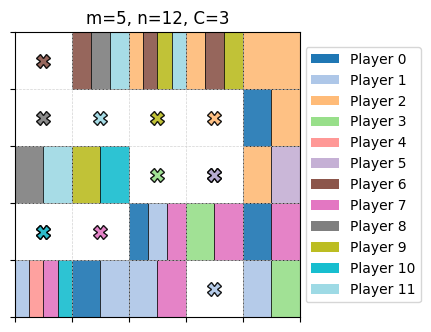

In [ ]:
heuristic_kwargs = {
    "max_rounds": 200,
    "delta": 0.5,
    "epsilon_scale": 0.1,
    "price_floor": 0.0,
}

results = []

instance = generate_grid_instance(
                    n=5,
                    m=12,
                    C=3,
                    max_cap=2,
                    max_budget=20,
                    max_utility=20,
                    rng_seed=883283,
                )

start = perf_counter()
result = run_grid_heuristic(instance, rng_seed=883283, **heuristic_kwargs)
history = result.get("meta", {}).get("history", [])
if history:
    avg_change_rate = sum(h.get("demand_change_rate", 0.0) for h in history) / len(history)
    avg_max_price = sum(h.get("max_price", 0.0) for h in history) / len(history)
    avg_price_std = sum(h.get("price_std", 0.0) for h in history) / len(history)
else:
    avg_change_rate = 0.0
    avg_max_price = 0.0
    avg_price_std = 0.0
elapsed = perf_counter() - start

results.append(
    {
        "grid": 5,
        "C": 3,
        "slack_found": result.get("slack"),
        "boosted": result.get("is_boosted", False),
        "equilibrium": result.get("equilibrium", False),
        "rounds": result.get("rounds"),
        "delta_final": result.get("delta"),
        "time_sec": elapsed,
        "avg_demand_change": avg_change_rate,
        "avg_max_price": avg_max_price,
        "avg_price_std": avg_price_std,
    }
)

df = pd.DataFrame(results) 
df.head()

# Pick one run to visualize
if not df.empty:
    row = df.iloc[0]
    viz_seed = int(rng.integers(0, 1_000_000))
    viz_instance = generate_grid_instance(
        n=int(row["grid"]),
        m=int(row["players"]),
        C=int(row["C"]),
        max_cap=max_cap,
        max_budget=max_budget,
        max_utility=max_utility,
        rng_seed=viz_seed,
    )
    viz_result = run_grid_heuristic(viz_instance, rng_seed=viz_seed, **heuristic_kwargs)
    draw_grid_solution(
        viz_instance,
        viz_result,
        title=f"m={row['grid']}, n={row['players']}, C={row['C']}",
    );


In [ ]:
# Save results table
output_csv = "grid_data/grid_simulation_results.csv"
df.to_csv(output_csv, index=False)
print(f"Saved results to {output_csv}")


Saved results to grid_simulation_results.csv


Saved grid_max_slack.png
Saved grid_avg_slack.png


(<Figure size 800x500 with 1 Axes>,
 <Axes: title={'center': 'Average Slack Needed vs C'}, xlabel='C', ylabel='Avg Slack'>)

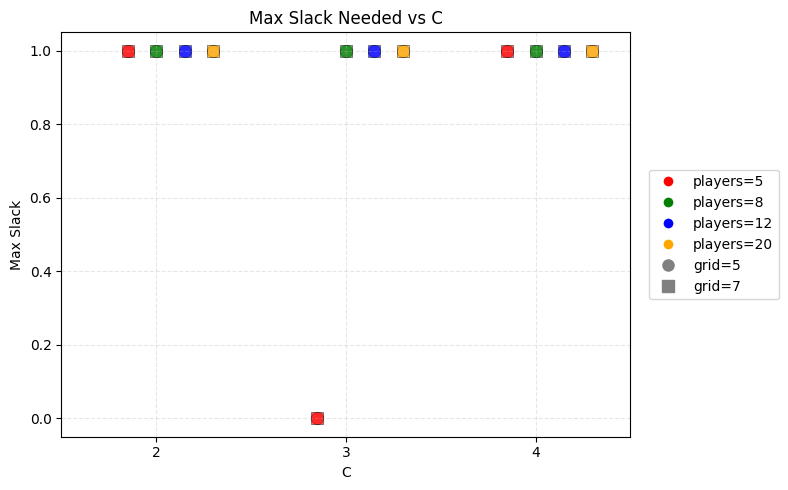

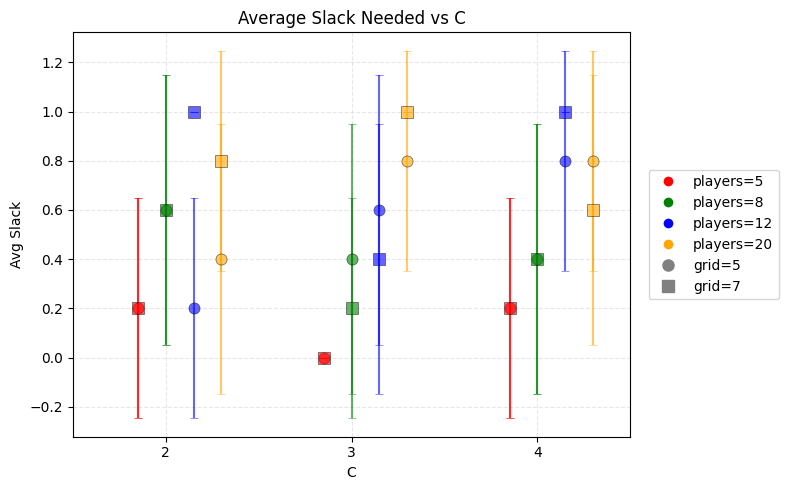

In [ ]:
# Plot slack vs C (avg and max) with 2-sigma error bars on averages
import matplotlib.pyplot as plt

# Use only successful runs for slack stats
df_ok = df[df["equilibrium"]].copy()

# Aggregate slack by grid size, player count, and C
agg = (
    df_ok.groupby(["grid", "players", "C"])
    .agg(
        avg_slack=("slack_found", "mean"),
        max_slack=("slack_found", "max"),
        std_slack=("slack_found", "std"),
        n=("slack_found", "count"),
    )
    .reset_index()
)

player_sizes = sorted(df["players"].unique())[:4]
grid_sizes = sorted(df["grid"].unique())[:2]

color_map = {player_sizes[0]: "red", player_sizes[1]: "green", player_sizes[2]: "blue", player_sizes[3]: "orange"}
marker_map = {grid_sizes[0]: "o", grid_sizes[1]: "s"}

# Horizontal offsets for the three player sizes
offsets = {player_sizes[0]: -0.15, player_sizes[1]: 0.0, player_sizes[2]: 0.15, player_sizes[3]: 0.3}
def _plot_slack(metric, title, filename, with_error=False):
    fig, ax = plt.subplots(figsize=(8, 5))
    for grid in grid_sizes:
        for players in player_sizes:
            subset = agg[(agg["grid"] == grid) & (agg["players"] == players)]
            if subset.empty:
                continue
            xs = subset["C"].to_numpy(dtype=float) + offsets[players]
            ys = subset[metric].to_numpy(dtype=float)
            if with_error:
                errs = 1.0 * subset["std_slack"].fillna(0.0).to_numpy(dtype=float)
                ax.errorbar(
                    xs,
                    ys,
                    yerr=errs,
                    fmt=marker_map[grid],
                    color=color_map[players],
                    alpha=0.6,
                    markersize=8,
                    markeredgecolor="black",
                    markeredgewidth=0.5,
                    capsize=3,
                    linestyle="None",
                )
            else:
                ax.scatter(
                    xs,
                    ys,
                    c=color_map[players],
                    marker=marker_map[grid],
                    alpha=0.6,
                    s=80,
                    edgecolor="black",
                    linewidth=0.5,
                )
    ax.set_xlabel("C")
    ax.set_ylabel(metric.replace("_", " ").title())
    ax.set_title(title)
    ax.set_xticks(sorted(df["C"].unique()))
    ax.grid(True, linestyle="--", alpha=0.3)
    ax.set_xlim(min(df["C"].unique()) - 0.5, max(df["C"].unique()) + 0.5)

    # Legends for colors (players) and markers (grid sizes)
    color_handles = [
        plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=color_map[p],
                   label=f"players={p}", markersize=8)
        for p in player_sizes
    ]
    marker_handles = [
        plt.Line2D([0], [0], marker=marker_map[g], color="gray", linestyle="None",
                   label=f"grid={g}", markersize=8)
        for g in grid_sizes
    ]
    ax.legend(handles=color_handles + marker_handles, loc="center left", bbox_to_anchor=(1.02, 0.5))

    fig.tight_layout()
    fig.savefig(filename, dpi=200)
    print(f"Saved {filename}")

    return fig, ax

_plot_slack("max_slack", "Max Slack Needed vs C", "grid_max_slack.png")
_plot_slack("avg_slack", "Average Slack Needed vs C", "grid_avg_slack.png", with_error=True)


Saved grid_5_avg_slack_vs_players_ci95.png
Saved grid_7_avg_slack_vs_players_ci95.png


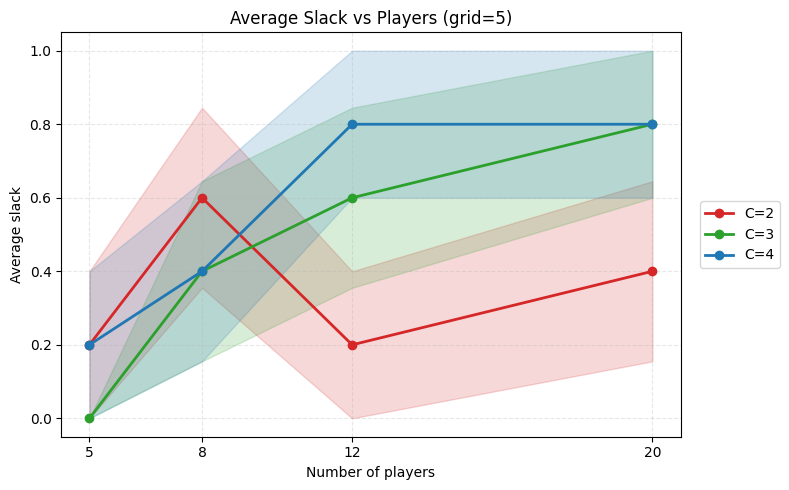

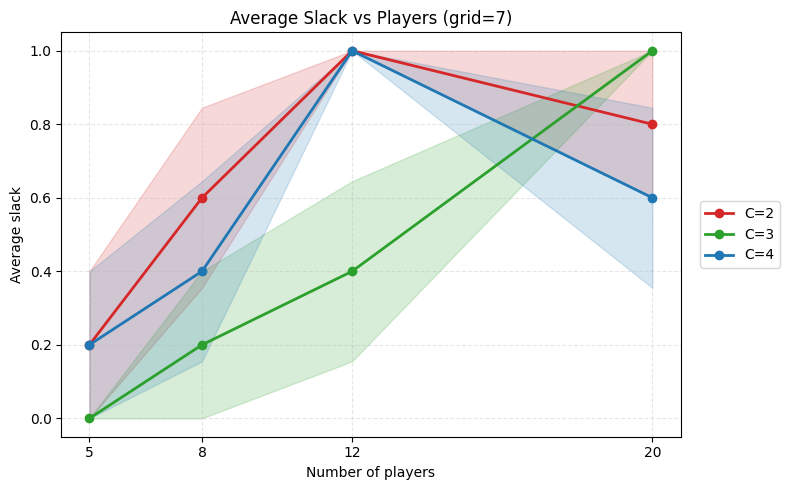

In [ ]:
# Per-grid avg slack vs players, with one line per C and 95% CI bands
import matplotlib.pyplot as plt
import numpy as np

line_colors = ["#d62728", "#2ca02c", "#1f77b4"]
all_C = sorted(df["C"].unique())[:3]
all_players = sorted(df["players"].unique())

line_stats = (
    df_ok.groupby(["grid", "players", "C"])
    .agg(
        avg_slack=("slack_found", "mean"),
        std_slack=("slack_found", "std"),
        n=("slack_found", "count"),
    )
    .reset_index()
)

for g in grid_sizes:
    fig, ax = plt.subplots(figsize=(8, 5))

    for idx, c_val in enumerate(all_C):
        subset = line_stats[(line_stats["grid"] == g) & (line_stats["C"] == c_val)].copy()
        if subset.empty:
            continue
        subset = subset.sort_values("players")
        xs = subset["players"].to_numpy(dtype=float)
        ys = subset["avg_slack"].to_numpy(dtype=float)
        stds = subset["std_slack"].fillna(0.0).to_numpy(dtype=float)
        ns = subset["n"].to_numpy(dtype=float)

        # 68% normal CI around mean: mean +/- 1.00 * std/sqrt(n)
        ci = np.where(ns > 0, 1.00 * stds / np.sqrt(ns), 0.0)
        lower = ys - ci
        upper = ys + ci

        ax.plot(
            xs,
            ys,
            marker="o",
            linewidth=2.0,
            color=line_colors[idx % len(line_colors)],
            label=f"C={c_val}",
        )
        ax.fill_between(
            xs,
            lower,
            upper,
            color=line_colors[idx % len(line_colors)],
            alpha=0.18,
        )

    ax.set_title(f"Average Slack vs Players (grid={g})")
    ax.set_xlabel("Number of players")
    ax.set_ylabel("Average slack")
    ax.set_xticks(all_players)
    ax.grid(True, linestyle="--", alpha=0.3)
    ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5))
    fig.tight_layout()
    out_name = f"grid_{g}_avg_slack_vs_players_ci95.png"
    fig.savefig(out_name, dpi=200)
    print(f"Saved {out_name}")


Saved grid_eq_rate.png
Saved grid_boost_rate.png
Saved grid_avg_rounds.png
Saved grid_avg_time.png


(<Figure size 800x500 with 1 Axes>,
 <Axes: title={'center': 'Average Runtime (s) vs C'}, xlabel='C', ylabel='Avg Time'>)

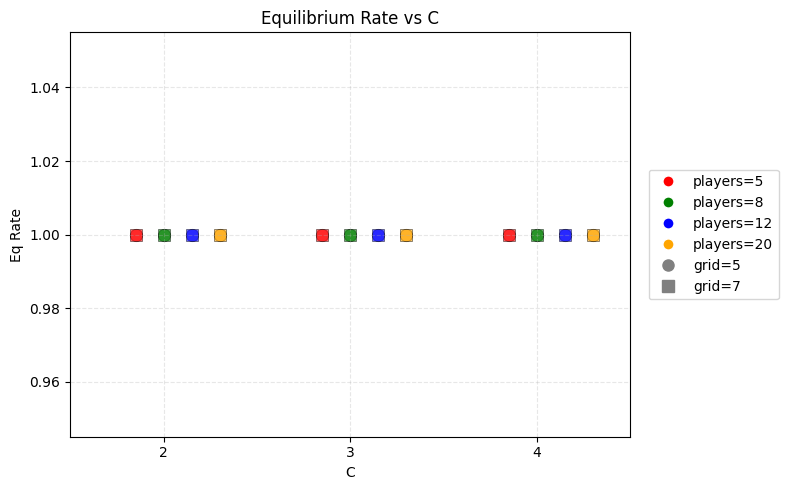

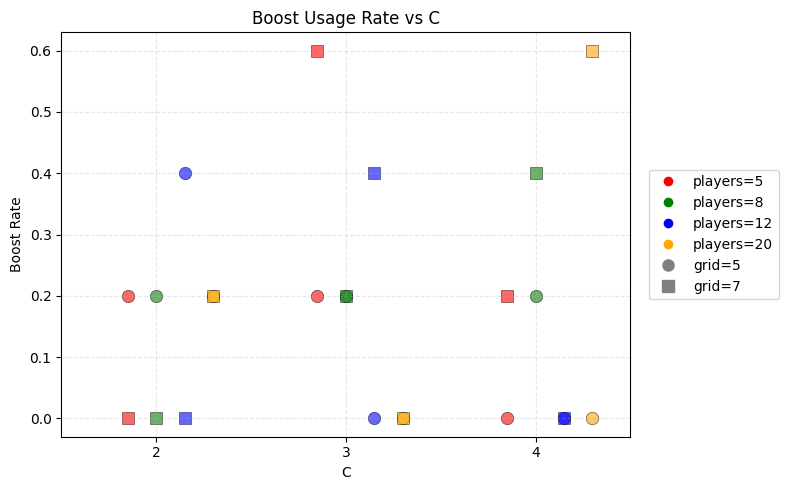

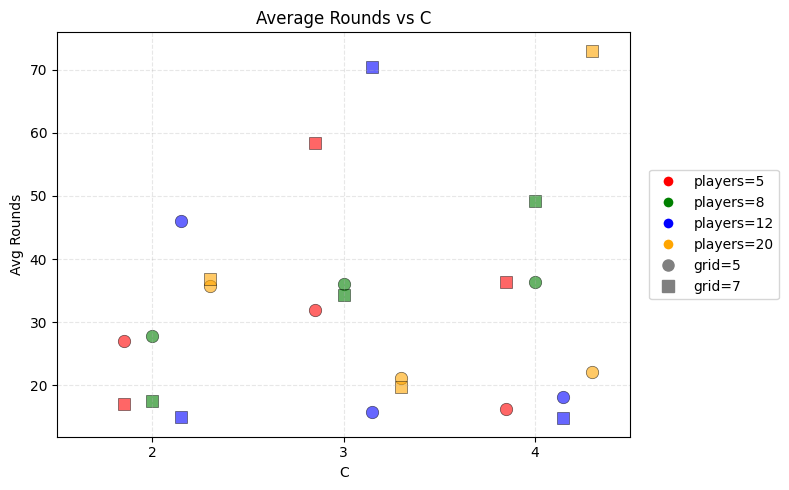

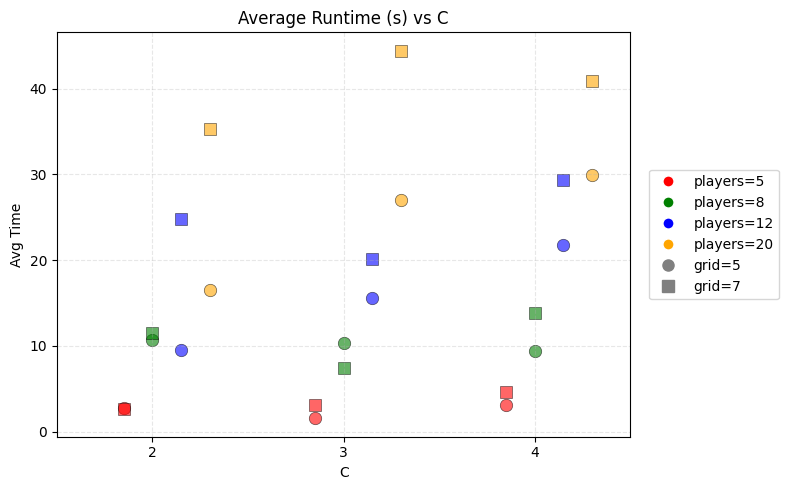

In [ ]:
# Additional performance plots
import matplotlib.pyplot as plt

perf = (
    df.groupby(["grid", "players", "C"])
    .agg(
        eq_rate=("equilibrium", "mean"),
        boost_rate=("boosted", "mean"),
        avg_rounds=("rounds", "mean"),
        avg_time=("time_sec", "mean"),
    )
    .reset_index()
)

def _legend_handles():
    color_handles = [
        plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=color_map[p],
                   label=f"players={p}", markersize=8)
        for p in player_sizes
    ]
    marker_handles = [
        plt.Line2D([0], [0], marker=marker_map[g], color="gray", linestyle="None",
                   label=f"grid={g}", markersize=8)
        for g in grid_sizes
    ]
    return color_handles + marker_handles

def _plot_metric(metric, title, filename):
    fig, ax = plt.subplots(figsize=(8, 5))
    for grid in grid_sizes:
        for players in player_sizes:
            subset = perf[(perf["grid"] == grid) & (perf["players"] == players)]
            if subset.empty:
                continue
            xs = subset["C"].to_numpy(dtype=float) + offsets[players]
            ys = subset[metric].to_numpy(dtype=float)
            ax.scatter(
                xs,
                ys,
                c=color_map[players],
                marker=marker_map[grid],
                alpha=0.6,
                s=80,
                edgecolor="black",
                linewidth=0.5,
            )
    ax.set_xlabel("C")
    ax.set_ylabel(metric.replace("_", " ").title())
    ax.set_title(title)
    ax.set_xticks(sorted(df["C"].unique()))
    ax.grid(True, linestyle="--", alpha=0.3)
    ax.set_xlim(min(df["C"].unique()) - 0.5, max(df["C"].unique()) + 0.5)
    ax.legend(handles=_legend_handles(), loc="center left", bbox_to_anchor=(1.02, 0.5))
    fig.tight_layout()
    fig.savefig(filename, dpi=200)
    print(f"Saved {filename}")
    return fig, ax

_plot_metric("eq_rate", "Equilibrium Rate vs C", "grid_eq_rate.png")
_plot_metric("boost_rate", "Boost Usage Rate vs C", "grid_boost_rate.png")
_plot_metric("avg_rounds", "Average Rounds vs C", "grid_avg_rounds.png")
_plot_metric("avg_time", "Average Runtime (s) vs C", "grid_avg_time.png")


Saved grid_avg_demand_change.png
Saved grid_avg_max_price.png
Saved grid_avg_price_std.png


(<Figure size 800x500 with 1 Axes>,
 <Axes: title={'center': 'Average Price Std Dev vs C'}, xlabel='C', ylabel='Avg Price Std'>)

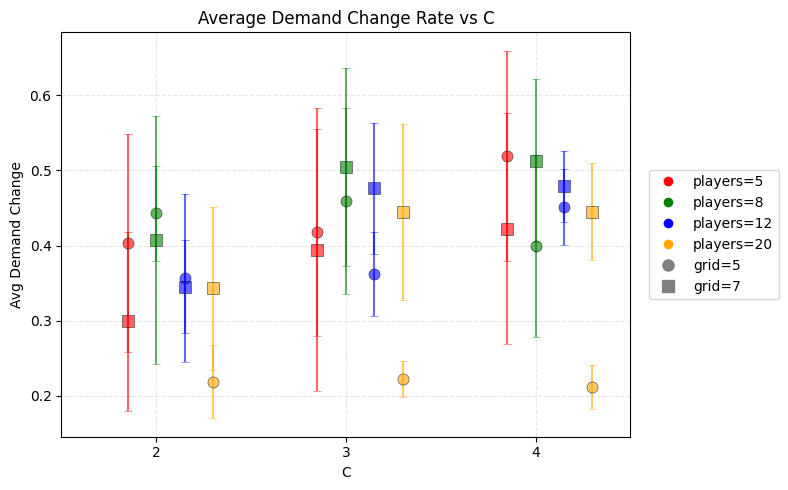

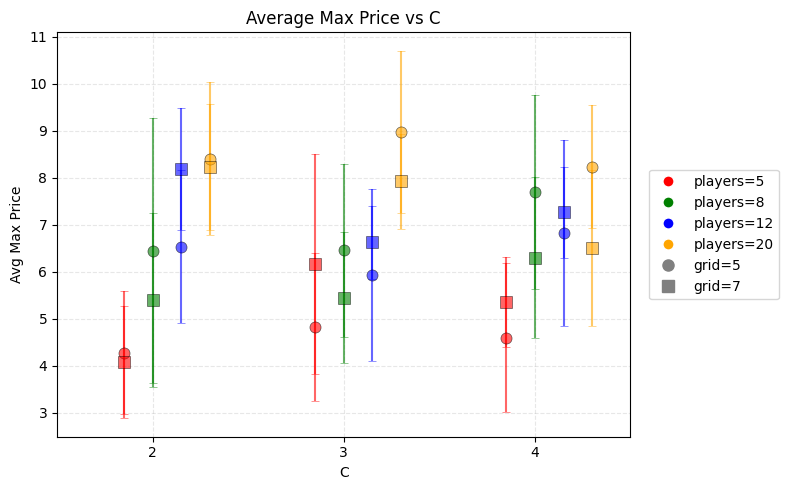

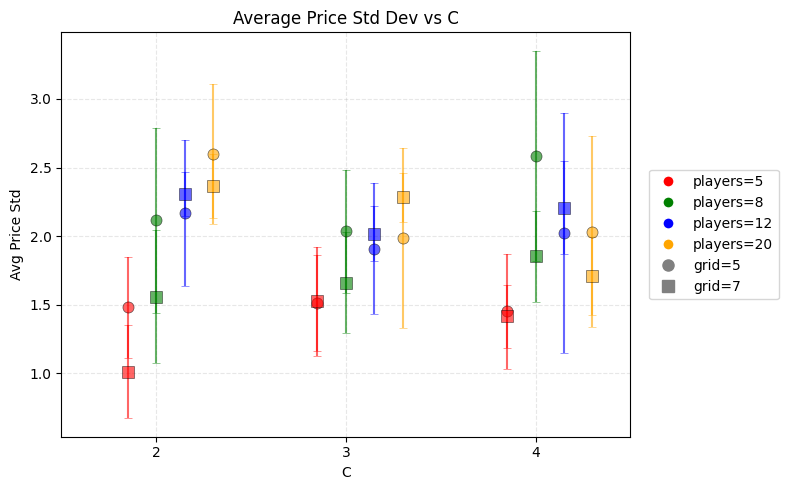

In [ ]:
# Demand/price dynamics plots
import matplotlib.pyplot as plt

dyn = (
    df.groupby(["grid", "players", "C"])
    .agg(
        avg_demand_change=("avg_demand_change", "mean"),
        std_demand_change=("avg_demand_change", "std"),
        avg_max_price=("avg_max_price", "mean"),
        std_max_price=("avg_max_price", "std"),
        avg_price_std=("avg_price_std", "mean"),
        std_price_std=("avg_price_std", "std"),
    )
    .reset_index()
)

std_col_map = {
    "avg_demand_change": "std_demand_change",
    "avg_max_price": "std_max_price",
    "avg_price_std": "std_price_std",
}

def _plot_dyn(metric, title, filename):
    fig, ax = plt.subplots(figsize=(8, 5))
    for grid in grid_sizes:
        for players in player_sizes:
            subset = dyn[(dyn["grid"] == grid) & (dyn["players"] == players)]
            if subset.empty:
                continue
            xs = subset["C"].to_numpy(dtype=float) + offsets[players]
            ys = subset[metric].to_numpy(dtype=float)
            errs = subset[std_col_map[metric]].fillna(0.0).to_numpy(dtype=float)
            ax.errorbar(
                xs,
                ys,
                yerr=errs,
                fmt=marker_map[grid],
                color=color_map[players],
                alpha=0.6,
                markersize=8,
                markeredgecolor="black",
                markeredgewidth=0.5,
                linestyle="None",
                capsize=3,
            )
    ax.set_xlabel("C")
    ax.set_ylabel(metric.replace("_", " ").title())
    ax.set_title(title)
    ax.set_xticks(sorted(df["C"].unique()))
    ax.grid(True, linestyle="--", alpha=0.3)
    ax.set_xlim(min(df["C"].unique()) - 0.5, max(df["C"].unique()) + 0.5)
    ax.legend(handles=_legend_handles(), loc="center left", bbox_to_anchor=(1.02, 0.5))
    fig.tight_layout()
    fig.savefig(filename, dpi=200)
    print(f"Saved {filename}")
    return fig, ax

_plot_dyn("avg_demand_change", "Average Demand Change Rate vs C", "grid_avg_demand_change.png")
_plot_dyn("avg_max_price", "Average Max Price vs C", "grid_avg_max_price.png")
_plot_dyn("avg_price_std", "Average Price Std Dev vs C", "grid_avg_price_std.png")


**Hill Climbing Algorithm for Manipulations**

In [ ]:
import os
import copy
import numpy as np
import pandas as pd
from GRID_generation import generate_grid_instance
from GRID_heuristic import hill_climb_manipulation_grid, run_grid_heuristic

# Ensure output directory exists
os.makedirs('./GRID_figs_new', exist_ok=True)


# Initialize our master lists with the 80-player data
summary_results = []
all_item_stats = []

# 2. Configurations for the NEW smaller runs
configs = [
    {"grid_size": 5, "num_players": 20},
    {"grid_size": 7, "num_players": 40}
]

# Shared parameters
C = 2
max_cap = 3
max_budget = 20
max_utility = 15
num_tries = 15
eta = 3.0
explore_samples = 7
verify_samples = 50
max_iters = 5
heuristic_kwargs = {"max_rounds": 30, "delta": 0.5, "epsilon_scale": 0.1, "price_floor": 0.0}

print("\nStarting Monte Carlo Search for new configurations...")

for conf in configs:
    g_size = conf["grid_size"]
    n_players = conf["num_players"]
    print(f"\n{'='*60}")
    print(f"Running Configuration: Grid {g_size}x{g_size}, Players: {n_players}")
    print(f"{'='*60}")

    pct_histories = []
    success_histories = []
    config_item_stats = []

    for trial in range(num_tries):
        trial_seed = 88888 + (n_players * 100) + trial
        np.random.seed(trial_seed)
        target_player = np.random.randint(0, n_players)

        # Generate base instance
        temp_instance = generate_grid_instance(
            n=g_size, m=n_players, C=C, 
            max_cap=max_cap, max_budget=max_budget, max_utility=max_utility, rng_seed=trial_seed
        )

        # Lock the public grid variables
        fixed_bases = [p["base"] for p in temp_instance["players"]]
        fixed_capacities = temp_instance["capacities"]
        trial_instance_params = {
            "n": g_size, "m": n_players, "C": C,
            "max_cap": max_cap, "max_budget": max_budget, "max_utility": max_utility,
            "fixed_bases": fixed_bases, "fixed_capacities": fixed_capacities
        }

        # Calculate "Market Average Surplus" for zero-baseline fallback
        base_result = run_grid_heuristic(temp_instance, rng_seed=trial_seed, **heuristic_kwargs)
        all_surpluses = []
        for p_idx, p_data in enumerate(temp_instance["players"]):
            bundle = base_result["demands"][p_idx]
            p_gross = sum(util for paths in p_data["paths"].values() for idx, util in paths if idx in bundle)
            p_cost = sum(base_result["prices"][idx] for idx in bundle)
            all_surpluses.append(max(0, p_gross - p_cost))
        avg_market_surplus = np.mean(all_surpluses)

        true_V_0 = copy.deepcopy(temp_instance["players"][target_player]["paths"])
        target_budget = temp_instance["budgets"][target_player]

        print(f"  Trial {trial+1}/{num_tries} | Player {target_player} | Budget: {target_budget:.1f}")

        # Run manipulation
        best_fake_bid, u_history, p_history = hill_climb_manipulation_grid(
            target_player_id=target_player,
            base_instance_params=trial_instance_params,
            target_budget=target_budget,
            true_V_i=true_V_0,
            eta=eta,
            explore_samples=explore_samples,
            verify_samples=verify_samples,
            max_iters=max_iters,
            heuristic_kwargs=heuristic_kwargs
        )

        # Pad histories
        padded_u = u_history.copy()
        while len(padded_u) < max_iters + 1: padded_u.append(padded_u[-1])
        padded_p = p_history.copy()
        while len(padded_p) < max_iters + 1: padded_p.append(padded_p[-1])

        base_u = padded_u[0]
        final_u = padded_u[-1]

        # --- SMART ZERO-BASELINE HANDLING ---
        # If baseline is 0, use the average market surplus (minimum 1.0) as the denominator
        denom = base_u if base_u > 0.01 else max(1.0, avg_market_surplus)
        pct_traj = [(u - base_u) / denom for u in padded_u]
        pct_histories.append(pct_traj)
        
        # Track Success
        success_traj = [1 if u > base_u + 1e-3 else 0 for u in padded_u]
        success_histories.append(success_traj)

        # Gather Item Stats if successful
        if final_u > base_u + 1e-3:
            num_items = temp_instance["num_items"]
            congestion = np.zeros(num_items)
            for p_idx, player in enumerate(temp_instance["players"]):
                if p_idx == target_player: continue 
                for path in player["paths"].values():
                    for item_idx, _ in path:
                        congestion[item_idx] += 1
                        
            price_deltas = padded_p[-1] - padded_p[0]
            
            for dir_name, path in true_V_0.items():
                for step_idx, (item_idx, true_util) in enumerate(path):
                    fake_util = best_fake_bid[dir_name][step_idx][1]
                    
                    config_item_stats.append({
                        'grid_size': g_size,
                        'num_players': n_players,
                        'item_idx': item_idx,
                        'congestion': congestion[item_idx],
                        'dP': price_deltas[item_idx],
                        'dV': fake_util - true_util
                    })

    # Save aggregated histories for this configuration
    summary_results.append({
        'grid_size': g_size,
        'num_players': n_players,
        'pct_histories': np.array(pct_histories),
        'success_histories': np.array(success_histories)
    })
    
    if config_item_stats:
        all_item_stats.append(pd.DataFrame(config_item_stats))

# Final Master Dataframe for all configurations
item_df_master = pd.concat(all_item_stats, ignore_index=True)
print("\nAll simulations complete and data merged!")

In [ ]:
item_df_master.to_csv( "grid_data/grid_manipulation_item_stats_all_configs_dense.csv", index=False)
np.save("grid_data/grid_manipulation_summary_results_MASTER_dense.npy", summary_results, allow_pickle=True)

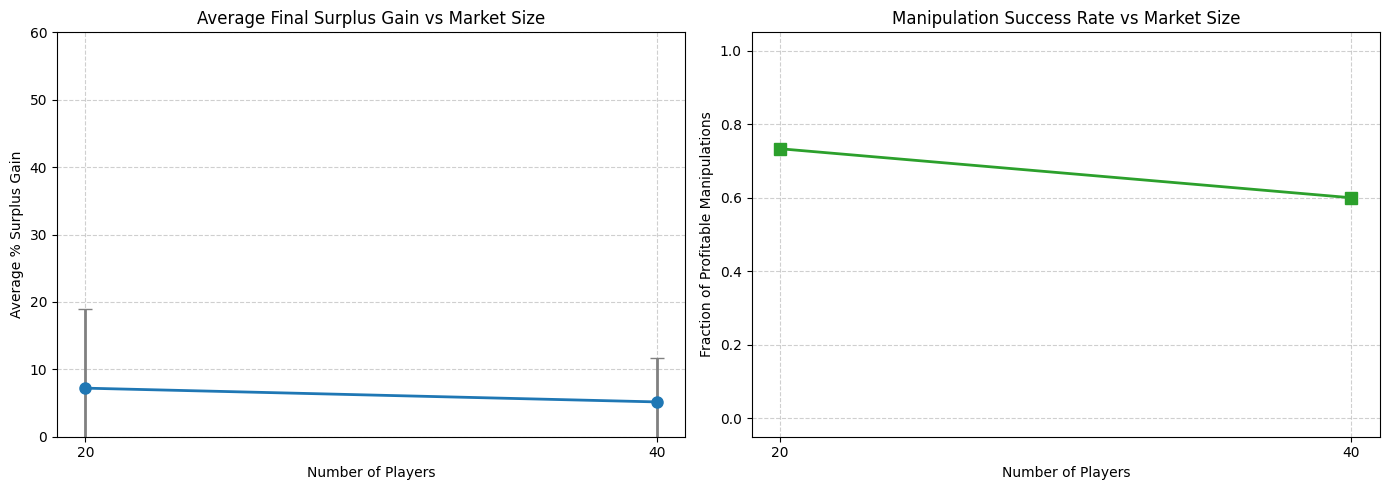

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Extract the final variables to plot
players = []
avg_pct_gain = []
pct_err = [] # List for gain error bars
success_rate = []
success_err = [] # List for success error bars

# Sort results by number of players so the line plots correctly left-to-right
#summary_results = np.load("grid_manipulation_summary_results_MASTER_dense.npy",allow_pickle=True)

for res in summary_results:
    players.append(res['num_players'])
    
    # Extract ONLY the last column (iteration 10) for the final result
    final_pcts = res['pct_histories'][:, -1]
    
    # Calculate averages and standard deviations (multiplied by 100 for percentage)
    avg_pct_gain.append(np.nanmean(final_pcts) * 100)
    pct_err.append(np.nanstd(final_pcts) * 100)
    
    # Handle success_histories: use it if it exists, otherwise derive it from final_pcts
    if res['success_histories'].size > 0:
        final_successes = res['success_histories'][:, -1]
    else:
        # Derive successes: creates a boolean array (True/False) and converts to 1.0/0.0
        final_successes = (final_pcts > 0).astype(float)
        
    # Calculate success averages and standard deviations
    success_rate.append(np.nanmean(final_successes))
    success_err.append(np.nanstd(final_successes))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: % Gain vs Num Players with Error Bars
axes[0].errorbar(players, avg_pct_gain, yerr=pct_err, 
                 marker='o', color='#1f77b4', linewidth=2, markersize=8,
                 capsize=5, capthick=1, ecolor='gray', label='Std. Dev.')
axes[0].set_title('Average Final Surplus Gain vs Market Size')
axes[0].set_xlabel('Number of Players')
axes[0].set_ylabel('Average % Surplus Gain')
axes[0].set_ylim(0, 60)
axes[0].set_xticks(players)
axes[0].grid(True, linestyle='--', alpha=0.6)

# Plot 2: Success Rate vs Num Players with Error Bars
axes[1].plot(players, success_rate, marker='s', color='#2ca02c', linewidth=2, markersize=8)
axes[1].set_title('Manipulation Success Rate vs Market Size')
axes[1].set_xlabel('Number of Players')
axes[1].set_ylabel('Fraction of Profitable Manipulations')
axes[1].set_ylim(-0.05, 1.05)
axes[1].set_xticks(players)
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
fig.savefig('./GRID_figs_new/unified_market_size_impact_with_errors_dense.png', dpi=300, bbox_inches='tight')
plt.show()

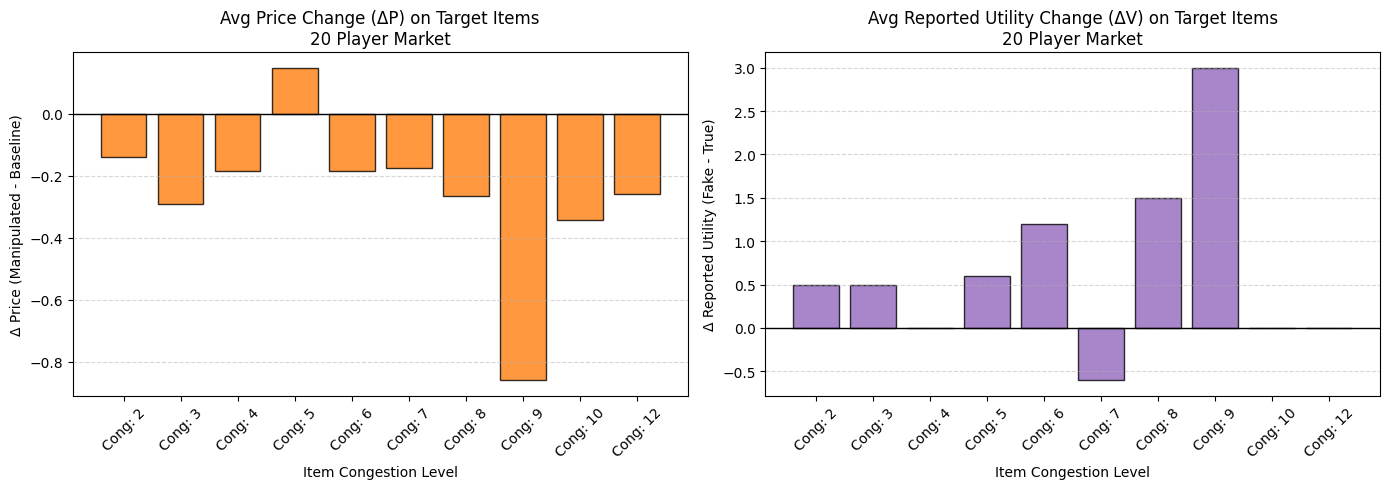

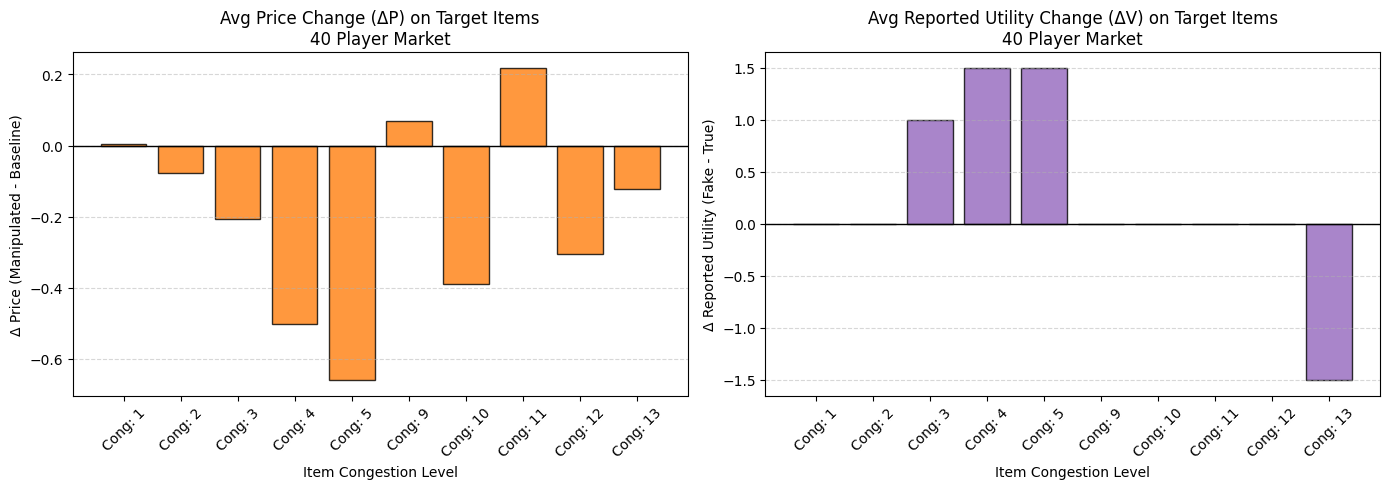

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

unique_configs = sorted(item_df_master['num_players'].unique())

for n_players in unique_configs:
    subset_df = item_df_master[item_df_master['num_players'] == n_players]
    
    if subset_df.empty:
        print(f"No successful manipulations to plot for {n_players} players.")
        continue

    # Group the items by their baseline congestion level to find averages
    agg_df = subset_df.groupby('congestion')[['dP', 'dV']].mean().reset_index()
    agg_df = agg_df.sort_values('congestion')
    
    # Extract the 5 least and 5 most congested categories found in the data
    least_congested = agg_df.head(5)
    most_congested = agg_df.tail(5)
    
    # Combine them (removing duplicates if there were fewer than 10 total congestion levels)
    combined = pd.concat([least_congested, most_congested]).drop_duplicates().sort_values('congestion')
    combined['label'] = combined['congestion'].apply(lambda c: f"Cong: {int(c)}")
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot Price Change vs Congestion
    axes[0].bar(combined['label'], combined['dP'], color='#ff7f0e', edgecolor='black', alpha=0.8)
    axes[0].set_title(f'Avg Price Change (ΔP) on Target Items\n{n_players} Player Market')
    axes[0].set_xlabel('Item Congestion Level')
    axes[0].set_ylabel('Δ Price (Manipulated - Baseline)')
    axes[0].axhline(0, color='black', linewidth=1)
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].grid(True, axis='y', linestyle='--', alpha=0.5)

    # Plot Utility Change vs Congestion
    axes[1].bar(combined['label'], combined['dV'], color='#9467bd', edgecolor='black', alpha=0.8)
    axes[1].set_title(f'Avg Reported Utility Change (ΔV) on Target Items\n{n_players} Player Market')
    axes[1].set_xlabel('Item Congestion Level')
    axes[1].set_ylabel('Δ Reported Utility (Fake - True)')
    axes[1].axhline(0, color='black', linewidth=1)
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].grid(True, axis='y', linestyle='--', alpha=0.5)

    plt.tight_layout()
    fig.savefig(f'./GRID_figs/item_level_analytics_{n_players}players.png', dpi=300, bbox_inches='tight')
    plt.show()

***ALPHA vs BETA tradeoffs***

In [ ]:
### ALPHA Prioritization version ###
import pandas as pd
from time import perf_counter
import numpy as np

from GRID_heuristic import run_grid_heuristic_2D_alpha

# Simulation parameters for Grid
grid_sizes = [5, 7]
player_counts = [5, 8, 12, 20]
path_lengths = [2, 3, 4]
num_trials = 5

max_cap = 3
max_budget = 20
max_utility = 15

heuristic_kwargs = {
    "max_rounds": 200,
    "delta": 0.5,
    "epsilon_scale": 0.1,
    "price_floor": 0.0,
}

results = []

for n in grid_sizes:
    for m in player_counts:
        for C in path_lengths:
            for trial in range(num_trials):
                # Assuming rng is a numpy random Generator created previously
                seed = int(rng.integers(0, 1_000_000)) 
                instance = generate_grid_instance(
                        n=n,
                        m=m,
                        C=C,
                        max_cap=max_cap,
                        max_budget=max_budget,
                        max_utility=max_utility,
                        rng_seed=seed,
                    )

                start = perf_counter()
                result = run_grid_heuristic_2D_alpha(instance, rng_seed=seed, **heuristic_kwargs)
                demands = result.get("demands", [])
                allocated_players = sum(1 for bundle in demands if len(bundle) > 0)
                allocation_rate = allocated_players / max(1, instance["num_players"])
                elapsed = perf_counter() - start

                history = result.get("meta", {}).get("history", [])
                if history:
                    avg_change_rate = sum(h.get("demand_change_rate", 0.0) for h in history) / len(history)
                    avg_max_price = sum(h.get("max_price", 0.0) for h in history) / len(history)
                    avg_price_std = sum(h.get("price_std", 0.0) for h in history) / len(history)
                else:
                    avg_change_rate = 0.0
                    avg_max_price = 0.0
                    avg_price_std = 0.0

                results.append(
                    {
                        "grid": n,
                        "players": m,
                        "C": C,
                        "trial": trial,
                        "alpha_found": result.get("alpha"),  
                        "beta_found": result.get("beta"),    
                        "boosted": result.get("is_boosted", False),
                        "equilibrium": result.get("equilibrium", False),
                        "rounds": result.get("rounds"),
                        "delta_final": result.get("delta"),
                        "time_sec": elapsed,
                        "avg_demand_change": avg_change_rate,
                        "avg_max_price": avg_max_price,
                        "avg_price_std": avg_price_std,
                        "allocated_players": allocated_players,
                        "allocation_rate": allocation_rate,
                    }
                    
                )
    print(f"Completed simulations for grid_size={n}")

df_A = pd.DataFrame(results)
df_A.describe()

Completed simulations for grid_size=5
Completed simulations for grid_size=7


,grid,players,C,trial,alpha_found,beta_found,rounds,delta_final,time_sec,avg_demand_change,avg_max_price,avg_price_std,allocated_players,allocation_rate
count,120.000000,120.000000,120.00000,120.000000,120.00000,120.0,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000
mean,6.000000,11.250000,3.00000,2.000000,0.45000,0.0,29.050000,0.466667,14.641514,0.398099,6.305794,1.856930,10.283333,0.945000
std,1.004193,5.652768,0.81992,1.420143,0.49958,0.0,27.624691,0.085340,14.222395,0.160933,2.101018,0.581536,4.678187,0.106387
min,5.000000,5.000000,2.00000,0.000000,0.00000,0.0,1.000000,0.250000,0.288878,0.100000,2.500000,0.754133,5.000000,0.550000
25%,5.000000,7.250000,2.00000,1.000000,0.00000,0.0,15.000000,0.500000,1.643330,0.280288,4.553819,1.484002,5.750000,0.916667
50%,6.000000,10.000000,3.00000,2.000000,0.00000,0.0,19.000000,0.500000,9.686480,0.366563,6.198972,1.761159,8.500000,1.000000
75%,7.000000,14.000000,4.00000,3.000000,1.00000,0.0,25.000000,0.500000,25.209153,0.521546,7.679741,2.220691,12.000000,1.000000
max,7.000000,20.000000,4.00000,4.000000,1.00000,0.0,142.000000,0.500000,45.265704,0.733333,11.783578,3.554259,20.000000,1.000000


In [ ]:
### BETA Prioritization version ###

import pandas as pd
from time import perf_counter
import numpy as np

from GRID_heuristic import run_grid_heuristic_2D_beta

# Simulation parameters for Grid
grid_sizes = [5, 7]
player_counts = [5, 8, 12, 20]
path_lengths = [2, 3, 4]
num_trials = 5

max_cap = 3
max_budget = 20
max_utility = 15

heuristic_kwargs = {
    "max_rounds": 200,
    "delta": 0.5,
    "epsilon_scale": 0.1,
    "price_floor": 0.0,
}

results = []

for n in grid_sizes:
    for m in player_counts:
        for C in path_lengths:
            for trial in range(num_trials):
                # Assuming rng is a numpy random Generator created previously
                seed = int(rng.integers(0, 1_000_000)) 
                instance = generate_grid_instance(
                        n=n,
                        m=m,
                        C=C,
                        max_cap=max_cap,
                        max_budget=max_budget,
                        max_utility=max_utility,
                        rng_seed=seed,
                    )

                start = perf_counter()
                result = run_grid_heuristic_2D_beta(instance, rng_seed=seed, **heuristic_kwargs)
                demands = result.get("demands", [])
                allocated_players = sum(1 for bundle in demands if len(bundle) > 0)
                allocation_rate = allocated_players / max(1, instance["num_players"])
                elapsed = perf_counter() - start

                history = result.get("meta", {}).get("history", [])
                if history:
                    avg_change_rate = sum(h.get("demand_change_rate", 0.0) for h in history) / len(history)
                    avg_max_price = sum(h.get("max_price", 0.0) for h in history) / len(history)
                    avg_price_std = sum(h.get("price_std", 0.0) for h in history) / len(history)
                else:
                    avg_change_rate = 0.0
                    avg_max_price = 0.0
                    avg_price_std = 0.0

                results.append(
                    {
                        "grid": n,
                        "players": m,
                        "C": C,
                        "trial": trial,
                        "alpha_found": result.get("alpha"),  
                        "beta_found": result.get("beta"),    
                        "boosted": result.get("is_boosted", False),
                        "equilibrium": result.get("equilibrium", False),
                        "rounds": result.get("rounds"),
                        "delta_final": result.get("delta"),
                        "time_sec": elapsed,
                        "avg_demand_change": avg_change_rate,
                        "avg_max_price": avg_max_price,
                        "avg_price_std": avg_price_std,
                        "allocated_players": allocated_players,
                        "allocation_rate": allocation_rate,
                    }
                )
    print(f"Completed simulations for grid_size={n}")

df_B = pd.DataFrame(results)
df_B.describe()

Completed simulations for grid_size=5
Completed simulations for grid_size=7


,grid,players,C,trial,alpha_found,beta_found,rounds,delta_final,time_sec,avg_demand_change,avg_max_price,avg_price_std,allocated_players,allocation_rate
count,120.000000,120.000000,120.00000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000
mean,6.000000,11.250000,3.00000,2.000000,0.275000,0.166667,38.858333,0.439583,22.793487,0.429973,6.898562,1.979517,10.325000,0.947083
std,1.004193,5.652768,0.81992,1.420143,0.448386,0.374241,31.006992,0.107472,25.759718,0.168791,2.430380,0.632314,4.740603,0.102630
min,5.000000,5.000000,2.00000,0.000000,0.000000,0.000000,9.000000,0.250000,0.439611,0.107692,2.653846,0.811051,5.000000,0.550000
25%,5.000000,7.250000,2.00000,1.000000,0.000000,0.000000,18.000000,0.500000,1.705001,0.305961,4.866434,1.505403,6.500000,0.916667
50%,6.000000,10.000000,3.00000,2.000000,0.000000,0.000000,23.000000,0.500000,8.130634,0.411458,6.674521,1.914245,9.000000,1.000000
75%,7.000000,14.000000,4.00000,3.000000,1.000000,0.000000,47.500000,0.500000,38.962392,0.569511,8.263604,2.372159,12.000000,1.000000
max,7.000000,20.000000,4.00000,4.000000,1.000000,1.000000,121.000000,0.500000,96.145936,0.830882,16.626723,4.276771,20.000000,1.000000


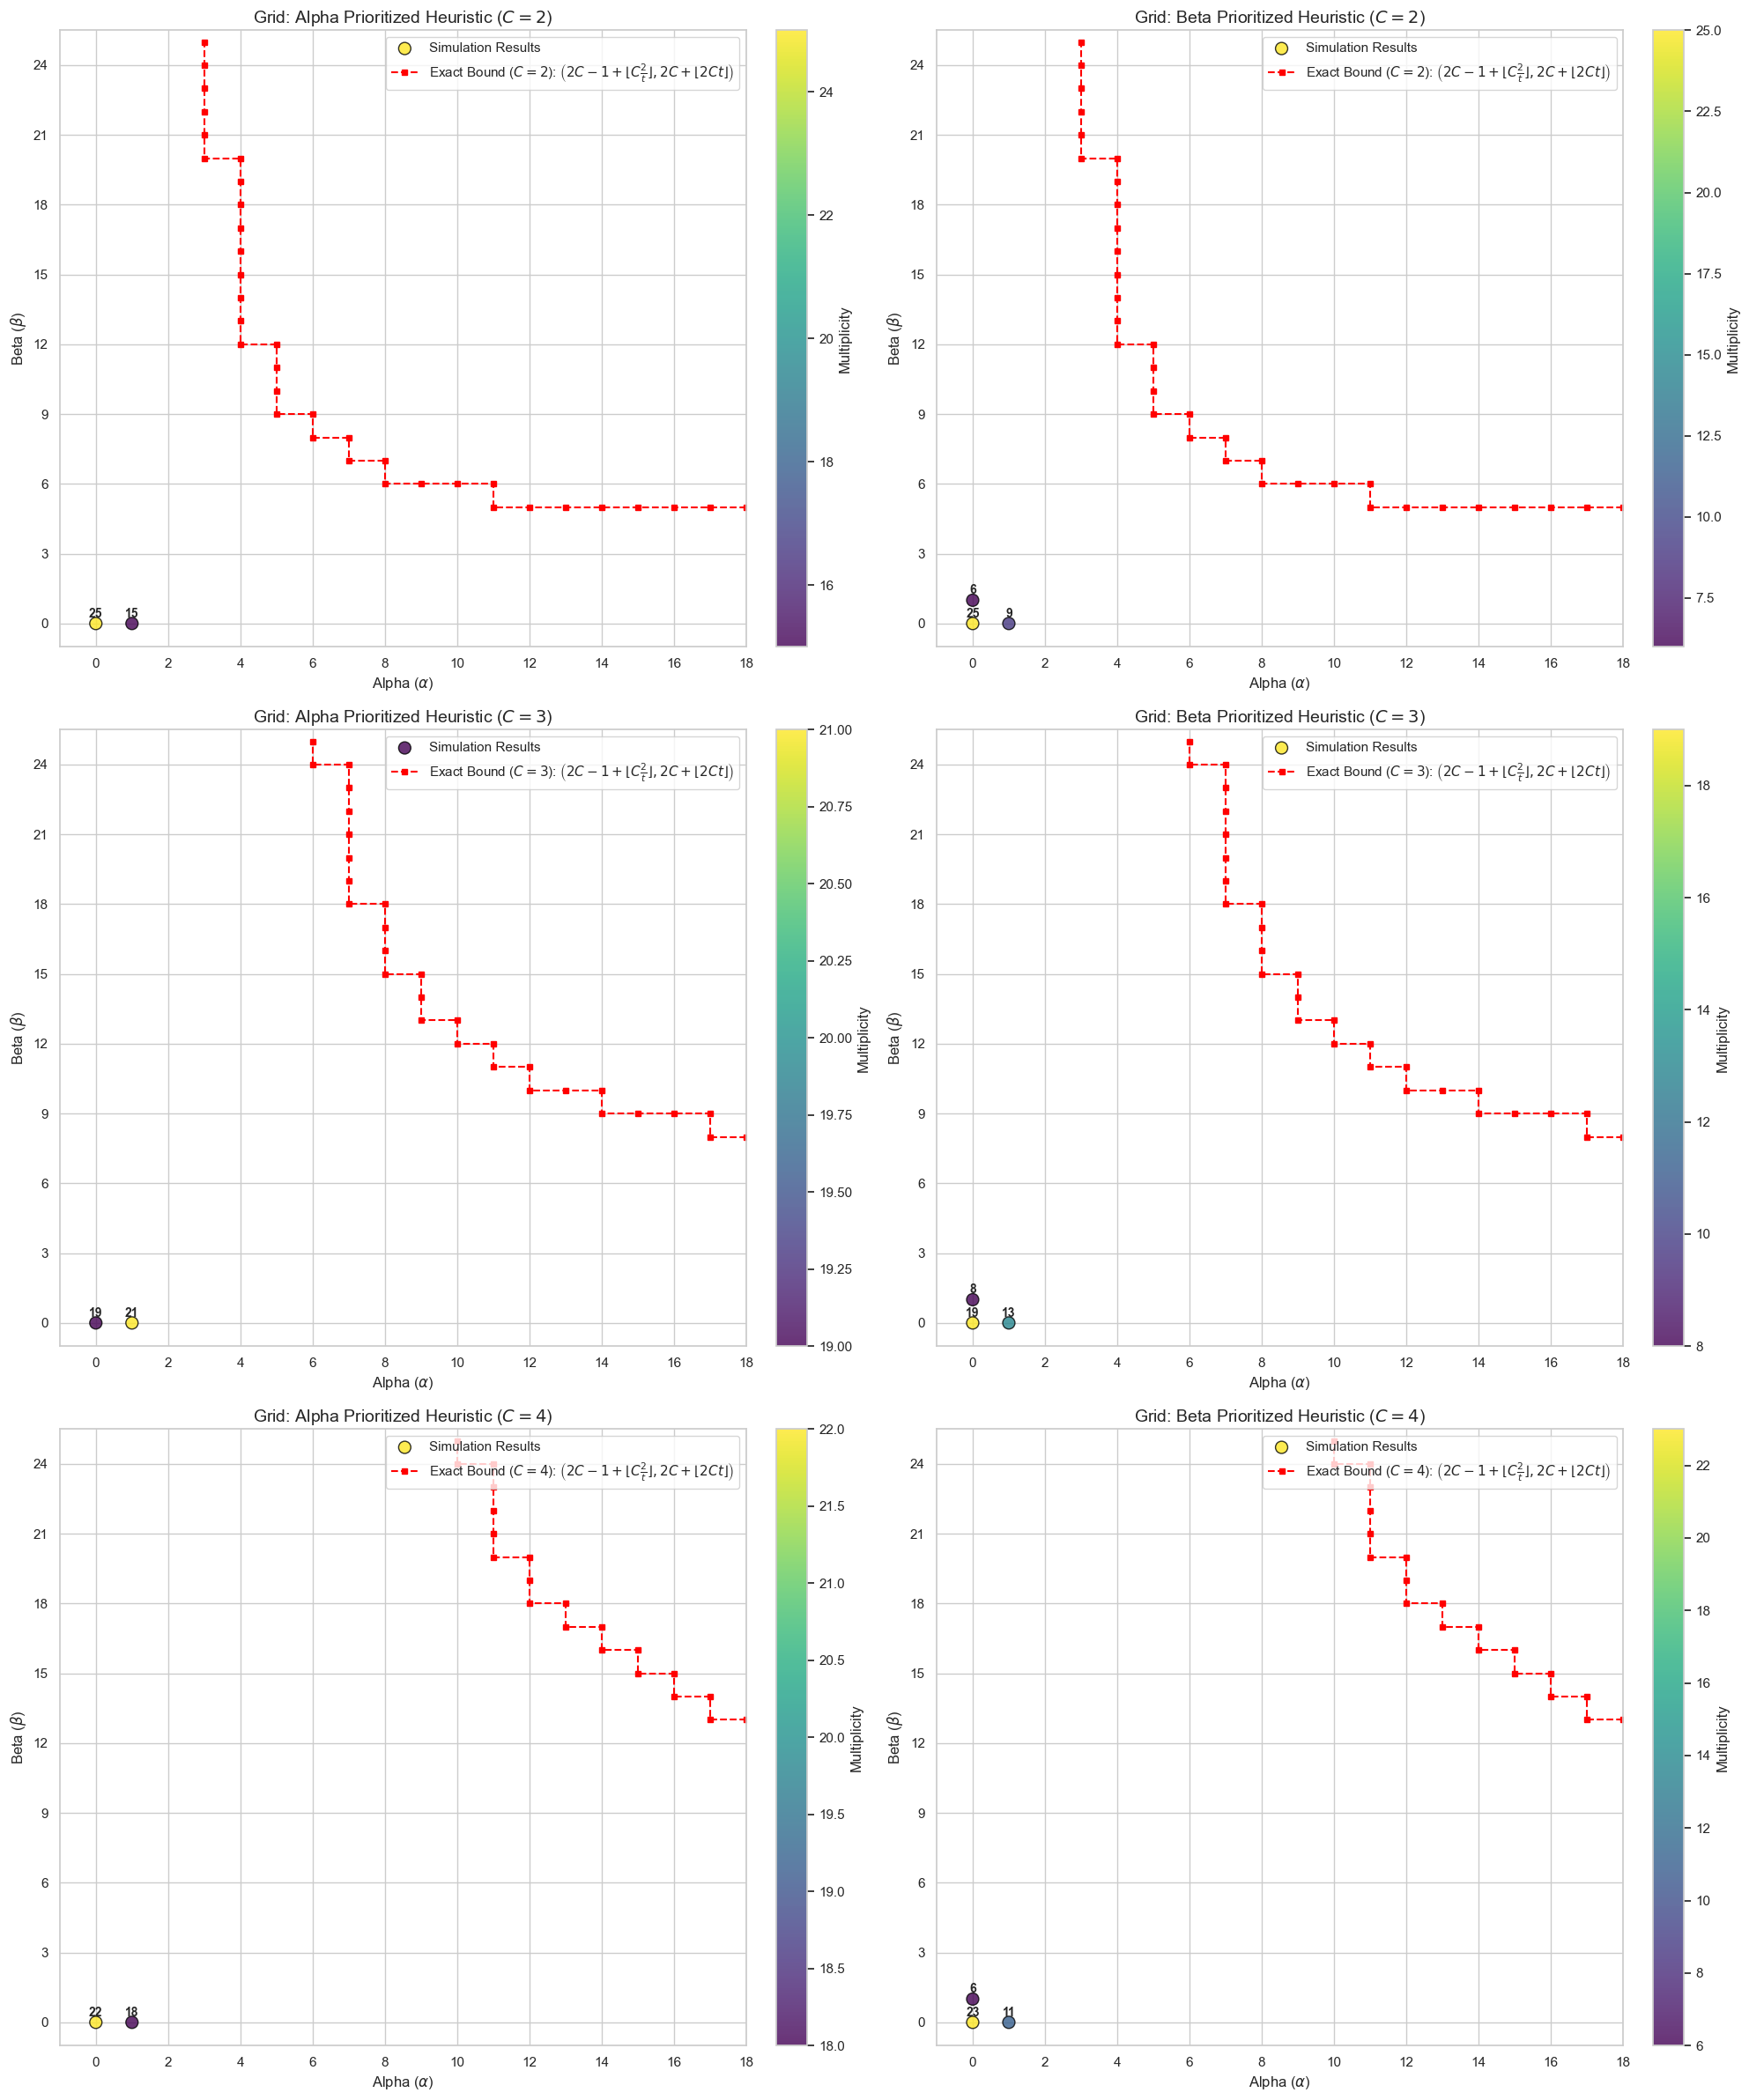

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

# Set the style for cleaner plots
sns.set_theme(style="whitegrid")

# Extract unique C values from both dataframes to ensure we cover all of them
unique_Cs = sorted(set(df_A['C'].unique()).union(df_B['C'].unique()))
num_rows = len(unique_Cs)

# Create a figure with a row for each C value, and 2 columns (df_A and df_B)
fig, axes = plt.subplots(num_rows, 2, figsize=(20, 8 * num_rows))

# Ensure axes is always a 2D array even if there is only 1 C value
if num_rows == 1:
    axes = [axes]

# Helper function to process and plot a single subplot
def plot_subplot(ax, df_subset, C_val, title, max_x, max_y):
    # 1. Group data to get multiplicity
    pair_counts = df_subset.groupby(['alpha_found', 'beta_found']).size().reset_index(name='multiplicity')

    # 2. Plot the (alpha, beta) pairs
    if not pair_counts.empty:
        scatter = ax.scatter(
            x=pair_counts['alpha_found'], 
            y=pair_counts['beta_found'], 
            s=100, 
            c=pair_counts['multiplicity'], 
            cmap='viridis', 
            edgecolors='black',
            alpha=0.8,
            zorder=3,
            label='Simulation Results'
        )
        # Add colorbar
        cbar = plt.colorbar(scatter, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label('Multiplicity')

        # 3. Write multiplicity above each point
        for _, row in pair_counts.iterrows():
            ax.text(
                row['alpha_found'], 
                row['beta_found'] + 0.15,  
                str(int(row['multiplicity'])),
                ha='center', 
                va='bottom',
                fontsize=10,
                fontweight='bold',
                zorder=4
            )

    # 4. Add the exact theoretical bound for this specific C value
    k_vals = np.arange(1, 500)
    m_vals = np.arange(1, 500)
    t_jumps_beta = k_vals / (2 * C_val)         
    t_jumps_alpha = (2 * C_val) / m_vals        
    t_dense = np.logspace(-2, 2, 10000)     

    t_vals = np.sort(np.unique(np.concatenate([t_dense, t_jumps_beta, t_jumps_alpha])))

    val_alpha = np.round((2 * C_val) / t_vals, 10)
    bound_alpha = (2 * C_val - 1) + np.floor(val_alpha)

    val_beta = np.round(2 * C_val * t_vals, 10)
    bound_beta = 2 * C_val + np.floor(val_beta)

    pairs = np.column_stack((bound_alpha, bound_beta))
    _, idx = np.unique(pairs, axis=0, return_index=True)
    bound_points = pairs[np.sort(idx)]

    valid_points = bound_points[(bound_points[:, 0] <= max_x) & (bound_points[:, 1] <= max_y)]

    ax.plot(
        valid_points[:, 0], 
        valid_points[:, 1], 
        color='red', 
        linestyle='--', 
        marker='s',        
        markersize=5,
        linewidth=1.5, 
        zorder=2,
        label=rf'Exact Bound ($C={C_val}$): $\left(2C-1+\lfloor C\frac{{2}}{{t}}\rfloor, 2C+ \lfloor 2C t\rfloor\right)$'
    )

    # 5. Formatting
    ax.set_title(title, fontsize=14)
    ax.set_xlabel(r'Alpha ($\alpha$)', fontsize=12)
    ax.set_ylabel(r'Beta ($\beta$)', fontsize=12)
    ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
    ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
    ax.set_xlim(-1, max_x)
    ax.set_ylim(-1, max_y)
    ax.legend(loc='upper right')

# Iterate through each unique C value and populate the row
for i, c_val in enumerate(unique_Cs):
    df_A_subset = df_A[df_A['C'] == c_val]
    df_B_subset = df_B[df_B['C'] == c_val]
    
    # Determine reasonable shared limits for this specific row/C-value
    max_alpha_A = df_A_subset['alpha_found'].max() if not df_A_subset.empty else 0
    max_alpha_B = df_B_subset['alpha_found'].max() if not df_B_subset.empty else 0
    max_x = max(max_alpha_A, max_alpha_B, 10) + 2

    max_beta_A = df_A_subset['beta_found'].max() if not df_A_subset.empty else 0
    max_beta_B = df_B_subset['beta_found'].max() if not df_B_subset.empty else 0
    max_y = max(max_beta_A, max_beta_B, 15) + 2

    # Plot Alpha Prioritized on the left column (0)
    plot_subplot(
        ax=axes[i][0], 
        df_subset=df_A_subset, 
        C_val=c_val, 
        title=f'Grid: Alpha Prioritized Heuristic ($C={c_val}$)', 
        max_x=1.5*max_x, 
        max_y=1.5*max_y
    )
    
    # Plot Beta Prioritized on the right column (1)
    plot_subplot(
        ax=axes[i][1], 
        df_subset=df_B_subset, 
        C_val=c_val, 
        title=f'Grid: Beta Prioritized Heuristic ($C={c_val}$)', 
        max_x=1.5*max_x, 
        max_y=1.5*max_y
    )

plt.tight_layout()
plt.show()

# Save the multi-panel plot explicitly under grid directory
os.makedirs("GRID_figs_new", exist_ok=True)
fig.savefig("GRID_figs_new/GRID_alpha_beta_distributions_by_C.png", dpi=200, bbox_inches='tight')